# Baseline Result Analysis

本 notebook 单独整理 LS / ACF / GPS / QP-GP 与标签周期的对照结果，便于作为论文中的基线结果分析与附图来源。

包含内容：
- 基线结果读取与指标汇总表
- 原始误差分布图与 label-vs-pred 图
- 额外补充的误差分布、ECDF、相关性与相对误差图
- 合并光变统计量后的描述性统计表


In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = Path('/Users/Zhuanz/Documents/Dissertation')

DATA_ROOT = PROJECT_ROOT / 'data' / 'kepler'

PALETTE = ['#4C72B0', '#55A868', '#C44E52', '#8172B3', '#64B5CD', '#DD8452', '#937860']
sns.set_theme(
    context='paper',
    style='whitegrid',
    font_scale=1.08,
    rc={
        'axes.spines.top': False,
        'axes.spines.right': False,
        'grid.linestyle': '--',
        'grid.alpha': 0.28,
    },
)
sns.set_palette(PALETTE)
plt.rcParams['figure.dpi'] = 110


def fd_bins(x, min_bins=12, max_bins=60):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    if len(x) < 2:
        return min_bins
    q75, q25 = np.percentile(x, [75, 25])
    iqr = q75 - q25
    if iqr == 0:
        return min_bins
    bin_width = 2 * iqr * (len(x) ** (-1 / 3))
    if bin_width <= 0:
        return min_bins
    bins = int(np.ceil((x.max() - x.min()) / bin_width))
    return int(np.clip(bins, min_bins, max_bins))


def read_csv_optional(path: Path) -> pd.DataFrame:
    if path.exists():
        return pd.read_csv(path)
    print(f'[WARN] Missing file: {path}')
    return pd.DataFrame()


In [2]:
lc_path = DATA_ROOT / 'lc_overview.csv'
baseline_path = DATA_ROOT / 'baseline_periods_ls_acf.csv'
catalog_path = DATA_ROOT / 'mcquillan2014_catalog.csv'

df_lc = read_csv_optional(lc_path)
df_base = read_csv_optional(baseline_path)
df_cat = read_csv_optional(catalog_path)

print('lc_overview:', df_lc.shape)
print('baseline:', df_base.shape)
print('catalog:', df_cat.shape)

df_merged = df_lc.copy()
if not df_base.empty and 'kic' in df_base.columns:
    keep_cols = [c for c in ['kic', 'prot_label', 'prot_ls', 'prot_acf', 'prot_gps', 'prot_qpgp'] if c in df_base.columns]
    df_merged = df_merged.merge(df_base[keep_cols], on='kic', how='left')

print('merged:', df_merged.shape)


lc_overview: (909, 9)
baseline: (909, 11)
catalog: (34030, 3)
merged: (909, 14)


## Metrics Summary

先把各方法的预测结果整理成长表，并汇总成更适合论文正文引用的指标表。


In [3]:
methods = [
    ('LS', 'prot_ls'),
    ('ACF', 'prot_acf'),
    ('GPS', 'prot_gps'),
    ('QP-GP', 'prot_qpgp'),
]
method_colors = {
    'LS': PALETTE[0],
    'ACF': PALETTE[2],
    'GPS': PALETTE[1],
    'QP-GP': PALETTE[3],
}

metric_rows = []
eval_frames = []

if not df_base.empty and 'prot_label' in df_base.columns:
    for name, col in methods:
        if col not in df_base.columns:
            continue
        keep = ['prot_label', col]
        if 'kic' in df_base.columns:
            keep = ['kic'] + keep
        tmp = df_base[keep].replace([np.inf, -np.inf], np.nan).dropna().copy()
        if tmp.empty:
            continue
        tmp = tmp.rename(columns={col: 'pred'})
        tmp['method'] = name
        tmp['err'] = tmp['pred'] - tmp['prot_label']
        tmp['abs_err'] = tmp['err'].abs()
        tmp['rel_err'] = tmp['abs_err'] / tmp['prot_label'].abs().replace(0, np.nan)
        eval_frames.append(tmp)

        metric_rows.append({
            'method': name,
            'N': len(tmp),
            'MAE': tmp['abs_err'].mean(),
            'RMSE': np.sqrt(np.mean(tmp['err'] ** 2)),
            'MedianAbsErr': tmp['abs_err'].median(),
            'Bias': tmp['err'].mean(),
            'MedianBias': tmp['err'].median(),
            'Frac(<10%)': (tmp['rel_err'] < 0.10).mean(),
            'Frac(<20%)': (tmp['rel_err'] < 0.20).mean(),
            'Corr(label,pred)': tmp['prot_label'].corr(tmp['pred']),
        })

eval_df = pd.concat(eval_frames, ignore_index=True) if eval_frames else pd.DataFrame()
metrics_df = pd.DataFrame(metric_rows)

if not metrics_df.empty:
    metrics_df = metrics_df.sort_values(['MAE', 'RMSE']).reset_index(drop=True)
    metrics_display = metrics_df.copy()
    for col in metrics_display.columns:
        if col != 'method' and metrics_display[col].dtype.kind in 'fc':
            metrics_display[col] = metrics_display[col].round(3)
    metrics_display
else:
    print('No valid baseline rows found.')


## Original Figures

保留原先的两组核心图：误差分布和 `label vs prediction`。这两组图最直接，适合正文或附录。


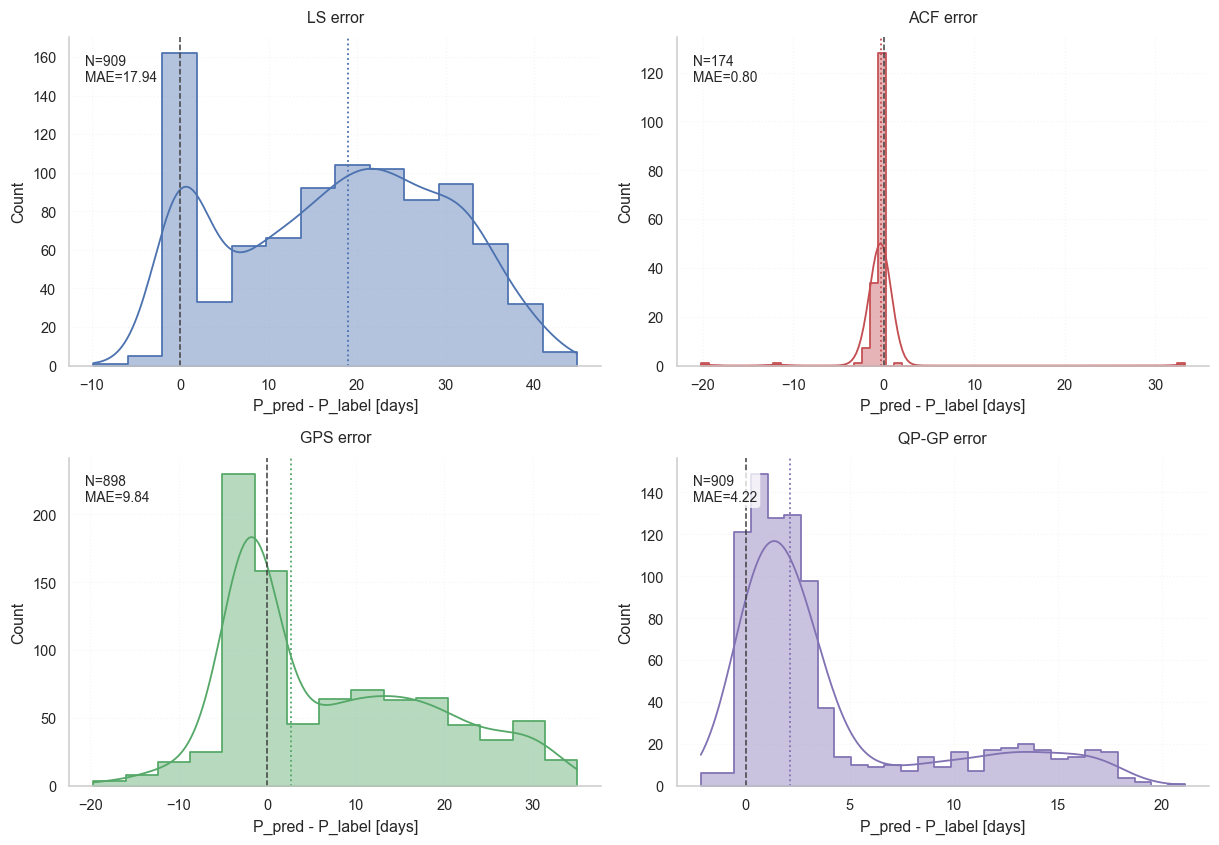

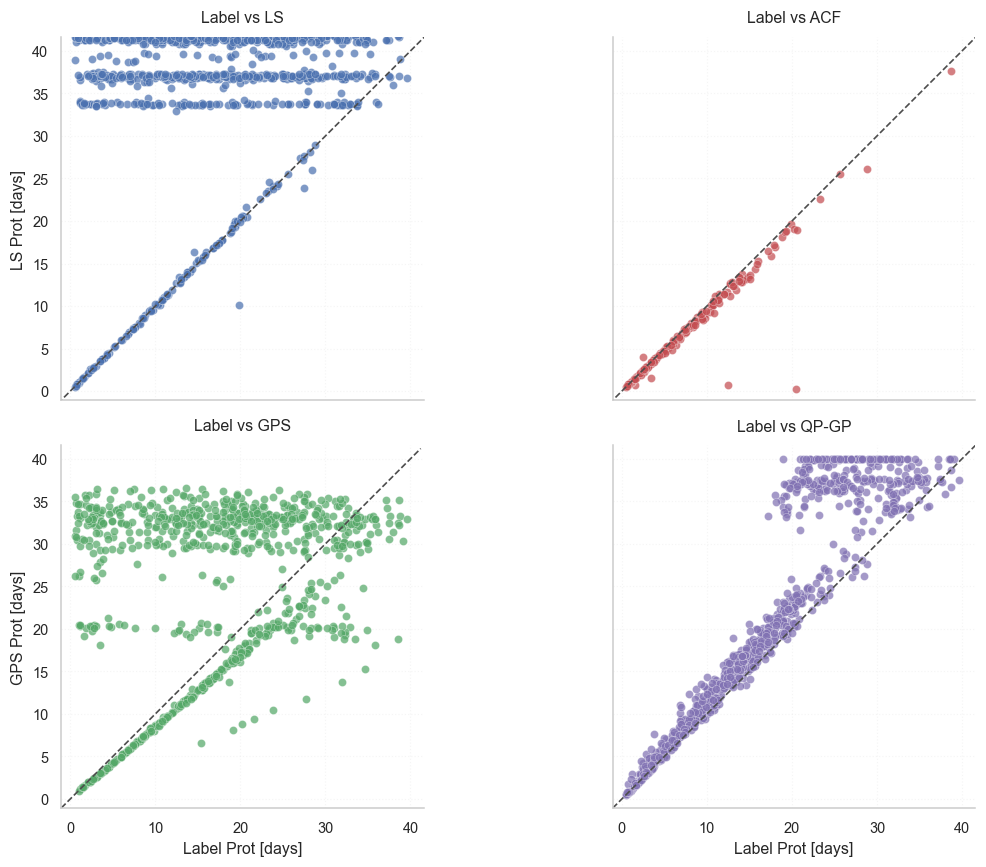

In [4]:
if not df_base.empty and 'prot_label' in df_base.columns:
    df_err = df_base.copy()

    fig, axes = plt.subplots(2, 2, figsize=(11.2, 7.8))
    axes = axes.ravel()
    for ax, (name, col) in zip(axes, methods):
        if col not in df_err.columns:
            ax.axis('off')
            continue
        err = (df_err[col] - df_err['prot_label']).replace([np.inf, -np.inf], np.nan).dropna()
        bins = fd_bins(err)
        sns.histplot(
            err,
            bins=bins,
            kde=True,
            stat='count',
            element='step',
            fill=True,
            alpha=0.42,
            linewidth=1.15,
            color=method_colors[name],
            ax=ax,
        )
        ax.axvline(0.0, linestyle='--', linewidth=1.0, color='0.25')
        ax.axvline(err.median(), linestyle=':', linewidth=1.2, color=method_colors[name])
        ax.set_title(f'{name} error', pad=10)
        ax.set_xlabel('P_pred - P_label [days]')
        ax.set_ylabel('Count')
        ax.grid(alpha=0.18, linestyle=':')
        ax.text(
            0.03,
            0.95,
            f'N={len(err)}\nMAE={err.abs().mean():.2f}',
            transform=ax.transAxes,
            va='top',
            ha='left',
            fontsize=9,
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.78, edgecolor='none'),
        )
    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(2, 2, figsize=(11.4, 8.0), sharex=True, sharey=True)
    axes = axes.ravel()
    for ax, (name, col) in zip(axes, methods):
        if col not in df_err.columns:
            ax.axis('off')
            continue
        plot_df = df_err[['prot_label', col]].replace([np.inf, -np.inf], np.nan).dropna()
        if plot_df.empty:
            ax.axis('off')
            continue
        lim_min = np.nanmin([plot_df['prot_label'].min(), plot_df[col].min()])
        lim_max = np.nanmax([plot_df['prot_label'].max(), plot_df[col].max()])
        pad = 0.04 * (lim_max - lim_min if lim_max > lim_min else 1.0)
        lims = [lim_min - pad, lim_max + pad]
        sns.scatterplot(
            data=plot_df,
            x='prot_label',
            y=col,
            s=28,
            alpha=0.72,
            linewidth=0.25,
            edgecolor='white',
            color=method_colors[name],
            ax=ax,
        )
        ax.plot(lims, lims, color='0.30', linewidth=1.1, linestyle='--')
        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.set_aspect('equal', 'box')
        ax.set_xlabel('Label Prot [days]')
        ax.set_ylabel(f'{name} Prot [days]')
        ax.set_title(f'Label vs {name}', pad=10)
        ax.grid(alpha=0.18, linestyle=':')
        if ax.legend_ is not None:
            ax.legend_.remove()
    plt.tight_layout()
    plt.show()


## Additional Figures

下面这些图更偏“论文配图”用途，用来展示不同方法的整体误差水平、尾部分布和相关结构。


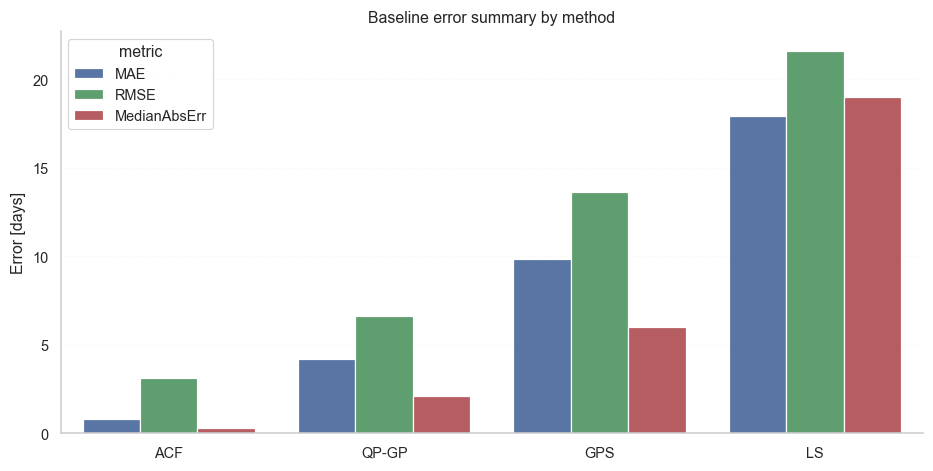

In [5]:
if not metrics_df.empty:
    plot_metrics = metrics_df.melt(
        id_vars='method',
        value_vars=['MAE', 'RMSE', 'MedianAbsErr'],
        var_name='metric',
        value_name='days',
    )

    plt.figure(figsize=(8.6, 4.4))
    sns.barplot(data=plot_metrics, x='method', y='days', hue='metric')
    plt.ylabel('Error [days]')
    plt.xlabel('')
    plt.title('Baseline error summary by method')
    plt.grid(axis='y', alpha=0.18, linestyle=':')
    plt.tight_layout()
    plt.show()


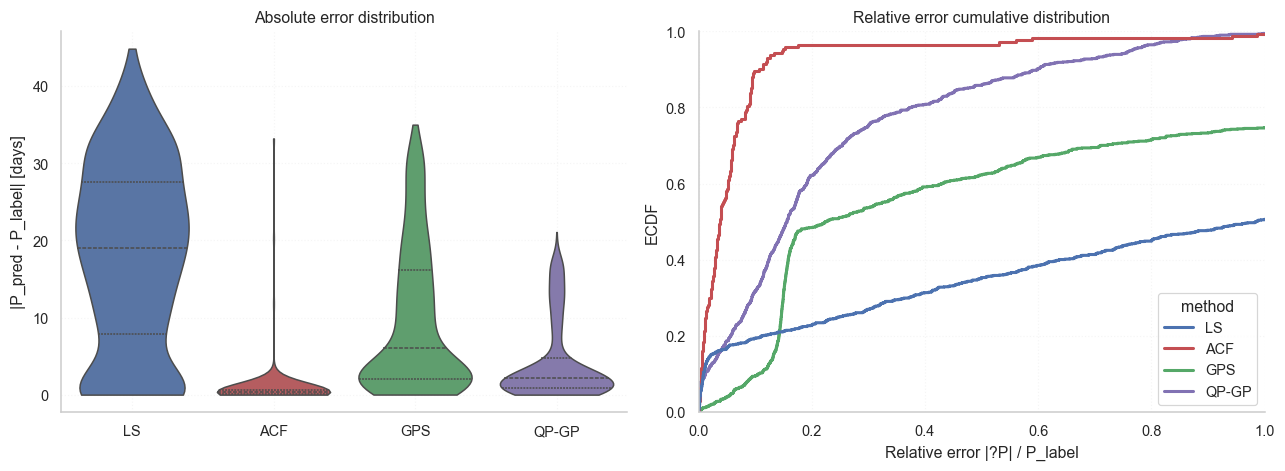

In [6]:
if not eval_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.4))

    sns.violinplot(
        data=eval_df,
        x='method',
        y='abs_err',
        order=[m[0] for m in methods if m[0] in eval_df['method'].unique()],
        palette=method_colors,
        inner='quartile',
        cut=0,
        ax=axes[0],
    )
    axes[0].set_title('Absolute error distribution')
    axes[0].set_xlabel('')
    axes[0].set_ylabel('|P_pred - P_label| [days]')
    axes[0].grid(alpha=0.18, linestyle=':')

    rel_df = eval_df.dropna(subset=['rel_err']).copy()
    sns.ecdfplot(
        data=rel_df,
        x='rel_err',
        hue='method',
        hue_order=[m[0] for m in methods if m[0] in rel_df['method'].unique()],
        palette=method_colors,
        linewidth=2.0,
        ax=axes[1],
    )
    axes[1].set_xlim(0, min(rel_df['rel_err'].quantile(0.95) * 1.1, 1.0))
    axes[1].set_xlabel('Relative error |?P| / P_label')
    axes[1].set_ylabel('ECDF')
    axes[1].set_title('Relative error cumulative distribution')
    axes[1].grid(alpha=0.18, linestyle=':')

    plt.tight_layout()
    plt.show()


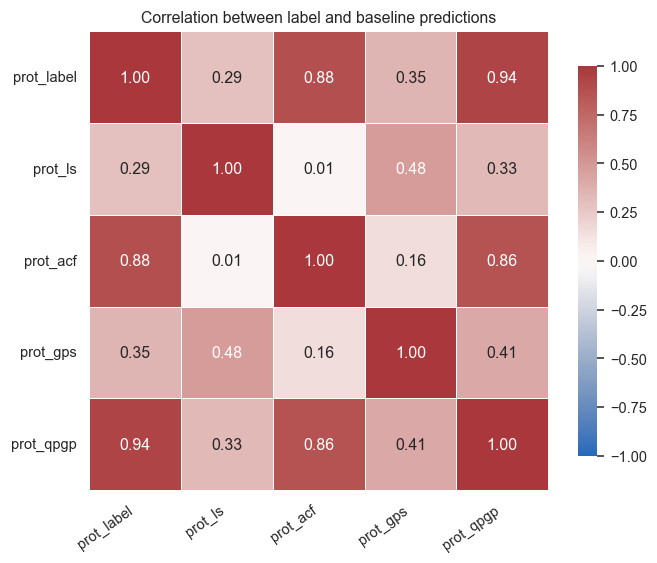

In [7]:
if not df_base.empty and 'prot_label' in df_base.columns:
    corr_cols = ['prot_label'] + [col for _, col in methods if col in df_base.columns]
    corr = df_base[corr_cols].replace([np.inf, -np.inf], np.nan).corr()

    plt.figure(figsize=(6.4, 5.2))
    sns.heatmap(
        corr,
        cmap='vlag',
        center=0,
        vmin=-1,
        vmax=1,
        annot=True,
        fmt='.2f',
        square=True,
        linewidths=0.5,
        cbar_kws={'shrink': 0.85},
    )
    plt.title('Correlation between label and baseline predictions')
    plt.xticks(rotation=35, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


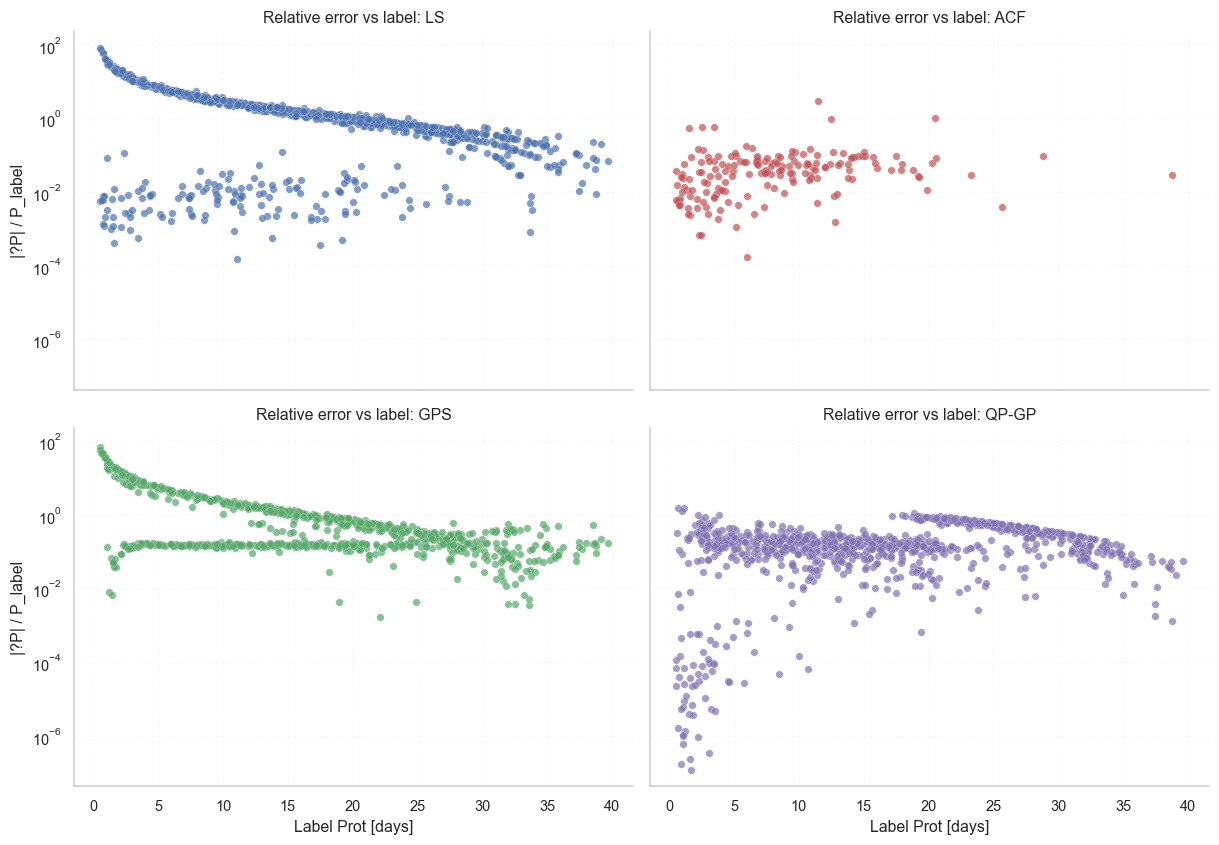

In [8]:
if not eval_df.empty:
    fig, axes = plt.subplots(2, 2, figsize=(11.2, 7.8), sharex=True, sharey=True)
    axes = axes.ravel()
    for ax, (name, _) in zip(axes, methods):
        tmp = eval_df[eval_df['method'] == name].dropna(subset=['prot_label', 'rel_err'])
        if tmp.empty:
            ax.axis('off')
            continue
        sns.scatterplot(
            data=tmp,
            x='prot_label',
            y='rel_err',
            s=24,
            alpha=0.70,
            linewidth=0.2,
            edgecolor='white',
            color=method_colors[name],
            ax=ax,
        )
        ax.set_yscale('log')
        ax.set_xlabel('Label Prot [days]')
        ax.set_ylabel('|?P| / P_label')
        ax.set_title(f'Relative error vs label: {name}')
        ax.grid(alpha=0.18, linestyle=':')
    plt.tight_layout()
    plt.show()


## Descriptive Statistics

把合并后的数值列做成描述性统计表，便于直接摘录到论文正文或附录中。


In [10]:
if not df_merged.empty:
    desc_cols = [
        c for c in [
            'n_points', 'time_span_days', 'cadence_minutes',
            'flux_median', 'flux_std', 'prot', 'teff',
            'prot_label', 'prot_ls', 'prot_acf', 'prot_gps', 'prot_qpgp',
        ] if c in df_merged.columns
    ]
    desc = df_merged[desc_cols].describe(percentiles=[0.25, 0.5, 0.75]).T.round(3)
    desc
else:
    print('No merged table available.')
